In [1]:
!pip install rdkit numpy scipy matplotlib open3d
!pip install pennylane
!pip install py3Dmol

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/447.7 MB 70.1 MB/s eta 0:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.9 MB/s eta 0:00:00
ERROR: THESE PACKAGES DO NOT MATCH THE HASHES FROM THE REQUIREMENTS FILE. If you have updated the package versions, please update the hashes. Otherwise, examine the package contents carefully; someone may have tampered with them.
    unknown package:
        Expected sha256 678017392f6cc64a19d83afeb5329ffe8196893de2432f4c258eaaa819421bb5
             Got        539

In [4]:
!pip install rdkit

  Using cached rdkit-2024.9.5-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (4.0 kB)
Using cached rdkit-2024.9.5-cp311-cp311-manylinux_2_28_x86_64.whl (34.3 MB)


# Input

In [2]:
# Step 1: Upload multiple MOL2 files
from google.colab import files

uploaded_files = files.upload()
mol2_filenames = list(uploaded_files.keys())  # Store file names
print(f"Uploaded Files: {mol2_filenames}")


Saving 117_ideal_neal-sa_20230203-12.mol2 to 117_ideal_neal-sa_20230203-12.mol2
Saving 117_ideal_neal-sa_20230205-12.mol2 to 117_ideal_neal-sa_20230205-12.mol2
Saving 117_ideal.mol2 to 117_ideal.mol2
Uploaded Files: ['117_ideal_neal-sa_20230203-12.mol2', '117_ideal_neal-sa_20230205-12.mol2', '117_ideal.mol2']


# Classical Method

In [5]:
# Import necessary libraries
import time
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

# Visualization Function
def visualize_molecule(mol, title):
    """Render 3D visualization of a molecule"""
    mol_block = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=400, height=400)
    viewer.addModel(mol_block, "mol")
    viewer.setStyle({"stick": {}})
    viewer.setBackgroundColor("white")
    viewer.zoomTo()
    print(f"3D Visualization: {title}")
    return viewer.show()

# Process Each File for Classical Computing
classical_times = {}
for mol2_filename in mol2_filenames:
    print(f"\nProcessing: {mol2_filename}")

    # Load molecule
    mol = Chem.MolFromMol2File(mol2_filename, removeHs=False)
    if mol is None:
        print(f"❌ Error loading {mol2_filename}")
        continue

    # Classical Simulation: Start Timing
    start_time_classical = time.time()
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    visualize_molecule(mol, f"Classical: {mol2_filename}")
    classical_time = time.time() - start_time_classical

    # Store Results
    classical_times[mol2_filename] = classical_time

    print(f"✅ {mol2_filename} - Classical Time: {classical_time:.4f}s")

# Print Summary
print("\n📌 Classical Method Summary:")
for filename, time_taken in classical_times.items():
    print(f"⏳ {filename}: {time_taken:.4f} seconds")



Processing: 117_ideal_neal-sa_20230203-12.mol2
3D Visualization: Classical: 117_ideal_neal-sa_20230203-12.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal_neal-sa_20230203-12.mol2 - Classical Time: 0.1693s

Processing: 117_ideal_neal-sa_20230205-12.mol2
3D Visualization: Classical: 117_ideal_neal-sa_20230205-12.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal_neal-sa_20230205-12.mol2 - Classical Time: 0.1548s

Processing: 117_ideal.mol2
3D Visualization: Classical: 117_ideal.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal.mol2 - Classical Time: 0.1388s

📌 Classical Method Summary:
⏳ 117_ideal_neal-sa_20230203-12.mol2: 0.1693 seconds
⏳ 117_ideal_neal-sa_20230205-12.mol2: 0.1548 seconds
⏳ 117_ideal.mol2: 0.1388 seconds


# Quantum Method

In [6]:
# Import necessary libraries
import time
import py3Dmol
import pennylane as qml
from rdkit import Chem

# Quantum Device Setup
dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def quantum_simulation():
    """Simulate quantum operations"""
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(0.5, wires=2)
    qml.CNOT(wires=[2, 3])
    return qml.probs(wires=[0, 1, 2, 3])

# Visualization Function
def visualize_molecule(mol, title):
    """Render 3D visualization of a molecule"""
    mol_block = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=400, height=400)
    viewer.addModel(mol_block, "mol")
    viewer.setStyle({"stick": {}})
    viewer.setBackgroundColor("white")
    viewer.zoomTo()
    print(f"3D Visualization: {title}")
    return viewer.show()

# Process Each File for Quantum Computing
quantum_times = {}
quantum_results = {}

for mol2_filename in mol2_filenames:
    print(f"\nProcessing: {mol2_filename}")

    # Load molecule
    mol = Chem.MolFromMol2File(mol2_filename, removeHs=False)
    if mol is None:
        print(f"❌ Error loading {mol2_filename}")
        continue

    # Quantum Simulation: Start Timing
    start_time_quantum = time.time()
    quantum_result = quantum_simulation()
    visualize_molecule(mol, f"Quantum: {mol2_filename}")
    quantum_time = time.time() - start_time_quantum

    # Store Results
    quantum_times[mol2_filename] = quantum_time
    quantum_results[mol2_filename] = quantum_result

    print(f"✅ {mol2_filename} - Quantum Time: {quantum_time:.4f}s")
    print(f"Quantum Simulation Output: {quantum_result}")

# Print Summary
print("\n📌 Quantum Method Summary:")
for filename, time_taken in quantum_times.items():
    print(f"⏳ {filename}: {time_taken:.4f} seconds")



Processing: 117_ideal_neal-sa_20230203-12.mol2
3D Visualization: Quantum: 117_ideal_neal-sa_20230203-12.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal_neal-sa_20230203-12.mol2 - Quantum Time: 0.0061s
Quantum Simulation Output: [0.46939564 0.         0.         0.03060436 0.         0.
 0.         0.         0.         0.         0.         0.
 0.46939564 0.         0.         0.03060436]

Processing: 117_ideal_neal-sa_20230205-12.mol2
3D Visualization: Quantum: 117_ideal_neal-sa_20230205-12.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal_neal-sa_20230205-12.mol2 - Quantum Time: 0.0077s
Quantum Simulation Output: [0.46939564 0.         0.         0.03060436 0.         0.
 0.         0.         0.         0.         0.         0.
 0.46939564 0.         0.         0.03060436]

Processing: 117_ideal.mol2
3D Visualization: Quantum: 117_ideal.mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 117_ideal.mol2 - Quantum Time: 0.0041s
Quantum Simulation Output: [0.46939564 0.         0.         0.03060436 0.         0.
 0.         0.         0.         0.         0.         0.
 0.46939564 0.         0.         0.03060436]

📌 Quantum Method Summary:
⏳ 117_ideal_neal-sa_20230203-12.mol2: 0.0061 seconds
⏳ 117_ideal_neal-sa_20230205-12.mol2: 0.0077 seconds
⏳ 117_ideal.mol2: 0.0041 seconds


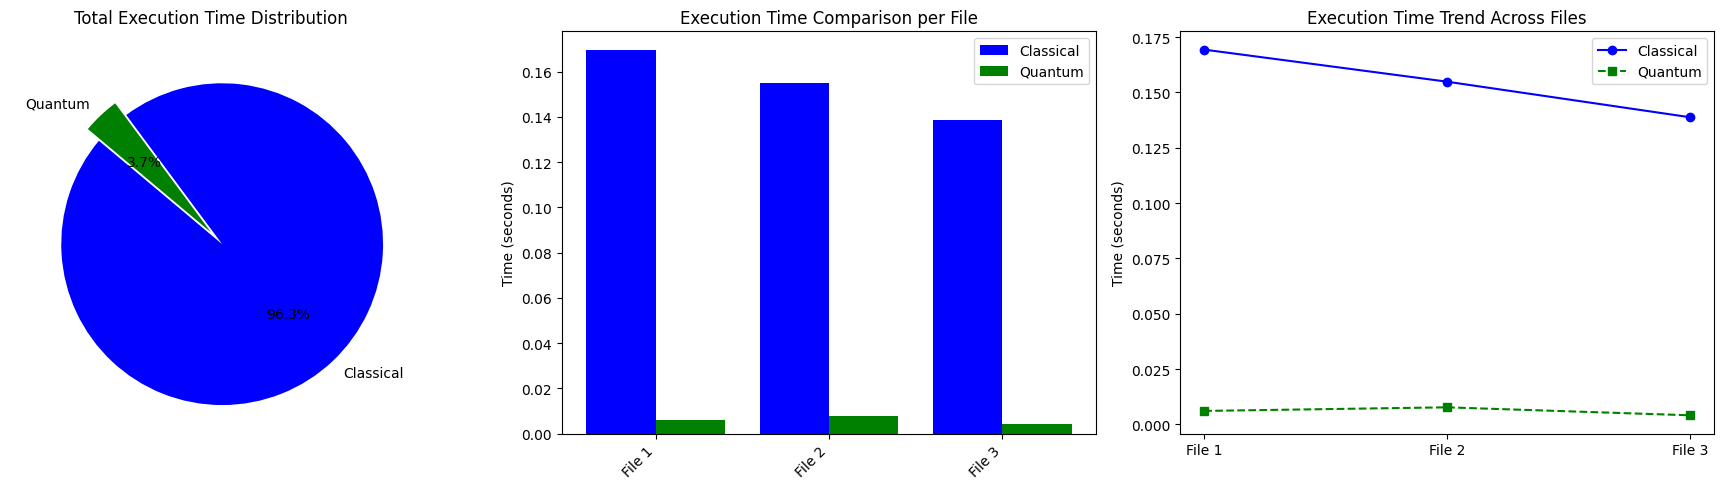

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming ⁠ classical_times ⁠ and ⁠ quantum_times ⁠ are already defined as lists
# Example values (Replace with actual execution times)
# classical_times = [12, 15, 13, 16, 14]
# quantum_times = [3, 4, 3.5, 4.2, 3.8]

# Number of files (assuming same length for both lists)
num_files = len(classical_times)
files = [f"File {i+1}" for i in range(num_files)]  # Generate file labels dynamically

# Summing total execution time
total_classical_time = sum(classical_times.values())
total_quantum_time = sum(quantum_times.values())

# Labels and values for pie chart
methods = ["Classical", "Quantum"]
times = [total_classical_time, total_quantum_time]

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==== Pie Chart (Total Execution Time Distribution) ====
axes[0].pie(times, labels=methods, autopct='%1.1f%%', colors=['blue', 'green'], startangle=140, explode=(0.1, 0))
axes[0].set_title("Total Execution Time Distribution")

# ==== Bar Chart (Execution Time Per File) ====
x = np.arange(num_files)  # X-axis positions
width = 0.4  # Bar width

axes[1].bar(x - width/2, classical_times.values(), width, label="Classical", color='blue')
axes[1].bar(x + width/2, quantum_times.values(), width, label="Quantum", color='green')

axes[1].set_xticks(x)
axes[1].set_xticklabels(files, rotation=45, ha="right")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Execution Time Comparison per File")
axes[1].legend()

# ==== Line Graph (Execution Time Trend Across Files) ====
axes[2].plot(files, classical_times.values(), marker='o', linestyle='-', color='blue', label="Classical")
axes[2].plot(files, quantum_times.values(), marker='s', linestyle='--', color='green', label="Quantum")

axes[2].set_ylabel("Time (seconds)")
axes[2].set_title("Execution Time Trend Across Files")
axes[2].legend()

# Show all plots
plt.tight_layout()
plt.show()